<center><img src='./Figs/cs-logo.png' width=200></center>



<h6><center></center></h6>

<h1>
<hr style=" border:none; height:3px;">
<center> Mention IA - CentraleSupélec - Visual Recognition  </center>
<hr style=" border:none; height:3px;">
</h1>


# Une petite application de réalité augmentée

Dans cette partie, vous allez mettre en place une application de réalité augmentée à bas coût comme illustrée ci-dessous

<center><img src='./Figs/AR.png' width=400></center>

Pour cela, nous devons dessiner une figure dont la position et l'orientation correspondent à la position et à l'orientation d'une surface plane prédéfinie. Il est donc nécessaire d'identifier la surface plane de référence dans une image ou une séquence vidéo. Une fois identifiée, nous pouvons facilement déterminer la transformation de l'image de la surface de référence (2D) vers l'image cible (2D). Cette transformation est une **homographie**. Puis, nous allons projeter un modèle 3D placé sur la surface de référence vers l'image cible. Il sera plus cela nécessaire d'étendre la transformation précédente pour traiter les cas où la hauteur du point à projeter dans le système de coordonnées de la surface de référence est différente de zéro. Enfin, il faudra appliquer cette transformation au modèle 3D et le dessiner à l'écran.

La figure ci-dessous représente ces différentes étapes

<center><img src='./Figs/ar-page-112.png' width=400></center>



### 1. Preparation des données
Importer les bibliothèques nécessaires comme OpenCV, Numpy, and Matplotlib.

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Polygon

### 2. Chargement des données

Il est nécessaire de charger deux images :
+ L'image de référence : image qui ne change pas et qui est utilisée comme référence
+ l'image source qui est alignée géométriquement avec l'image de référence. 

Pour commencer, vous allez travailler avec les images qui sont dans le répertoire [./data](./data). 




**Charger l'image de référence**

Charger l'image de référence, la convertir en niveaux de gris et afficher la.

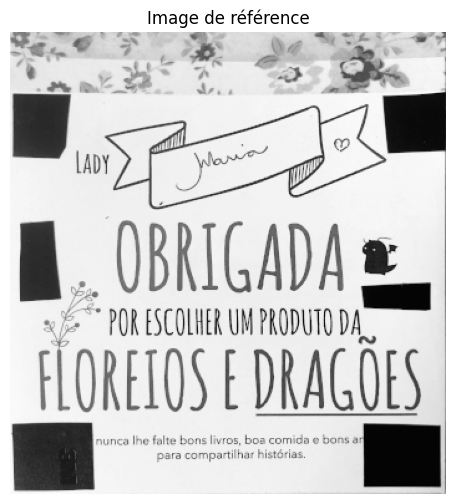

Dimensions de l'image de référence: (371, 350)


In [24]:
# Charger l'image de référence
reference_image_path = './data/referenceImage.jpg'
model = cv2.imread(reference_image_path)
model_gray = cv2.cvtColor(model, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(model_gray, cmap='gray')
plt.title('Image de référence')
plt.axis('off')
plt.show()

print(f"Dimensions de l'image de référence: {model_gray.shape}")

**Charger l'image source**

Charger l'image source, la convertir en niveaux de gris et afficher la. Il y a plusieurs images source dans le répertoire data, vous pourrez faire le travail avec l'image de votre choix ici.

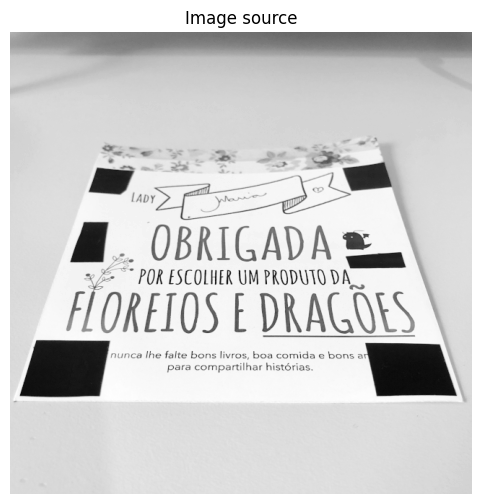

Dimensions de l'image source: (640, 640)


In [25]:
source_image_path = './data/sourceImage_01.jpg'
scene = cv2.imread(source_image_path)
scene_gray = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(scene_gray, cmap='gray')
plt.title('Image source')
plt.axis('off')
plt.show()

print(f"Dimensions de l'image source: {scene_gray.shape}")

### 3. Extraction de caractéristiques

Cette étape consiste à rechercher dans les images de référence et de destination les caractéristiques qui ressortent et qui, d'une certaine manière, décrivent une partie de l'objet à reconnaître. Ces caractéristiques peuvent être utilisées ultérieurement pour trouver l'objet de référence dans l'image cible. Nous supposerons que nous avons trouvé l'objet lorsqu'un certain nombre de caractéristiques positives sont trouvées entre l'image cible et l'image de référence.

 Pour que cela fonctionne, il est important d'avoir une image de référence où la seule chose vue est l'objet (ou la surface, dans ce cas) à trouver.  Nous ne voulons pas détecter des caractéristiques qui ne font pas partie de la surface.

 Il s'agit donc ici d'extraire des points d'intérêts tels que ceux vus en cours. Vous proposerez ici deux versions, une première version avec des détecteurs [SIFT](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html) et une deuxième version avec [ORB](https://docs.opencv.org/3.4/d1/d89/tutorial_py_orb.html).

**Avec SIFT**
Mettre en place la chaine d'extraction et de description de caractéristiques SIFT sur l'image de référence et sur l'image source choisie.

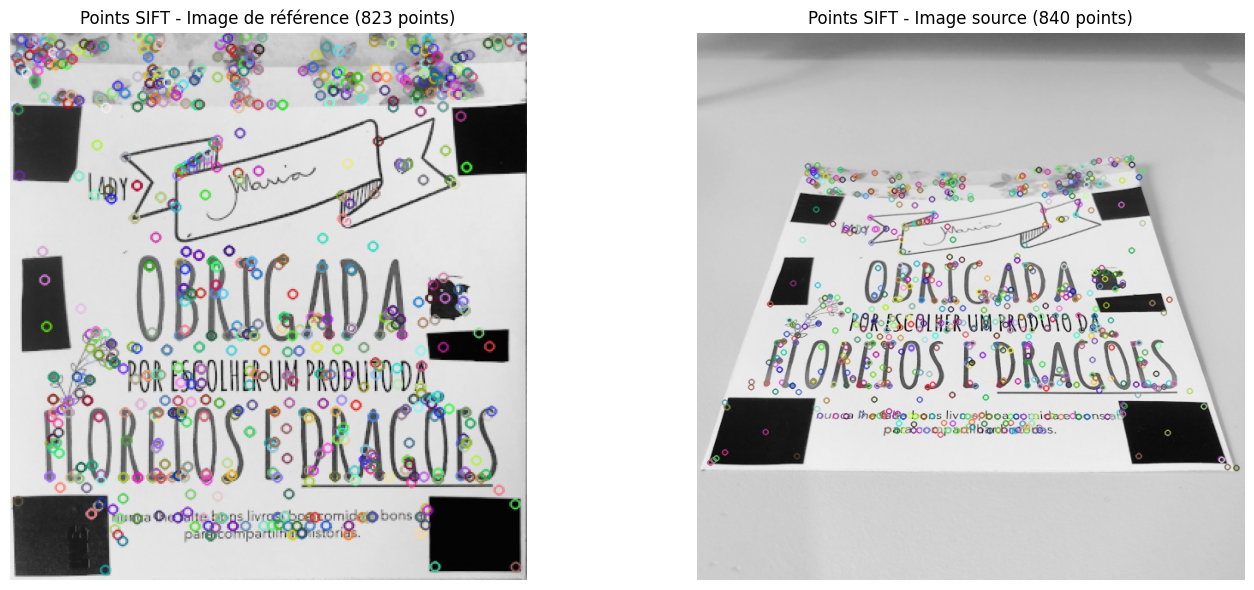

In [26]:
sift = cv2.SIFT_create()

kp_model_sift, des_model_sift = sift.detectAndCompute(model_gray, None)
kp_scene_sift, des_scene_sift = sift.detectAndCompute(scene_gray, None)

model_sift_display = cv2.drawKeypoints(model_gray, kp_model_sift, None)
scene_sift_display = cv2.drawKeypoints(scene_gray, kp_scene_sift, None)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(cv2.cvtColor(model_sift_display, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Points SIFT - Image de référence ({len(kp_model_sift)} points)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(scene_sift_display, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Points SIFT - Image source ({len(kp_scene_sift)} points)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**Avec ORB**
Mettre en place la chaine d'extraction et de description de caractéristiques SIFT sur l'image de référence et sur l'image source choisie.

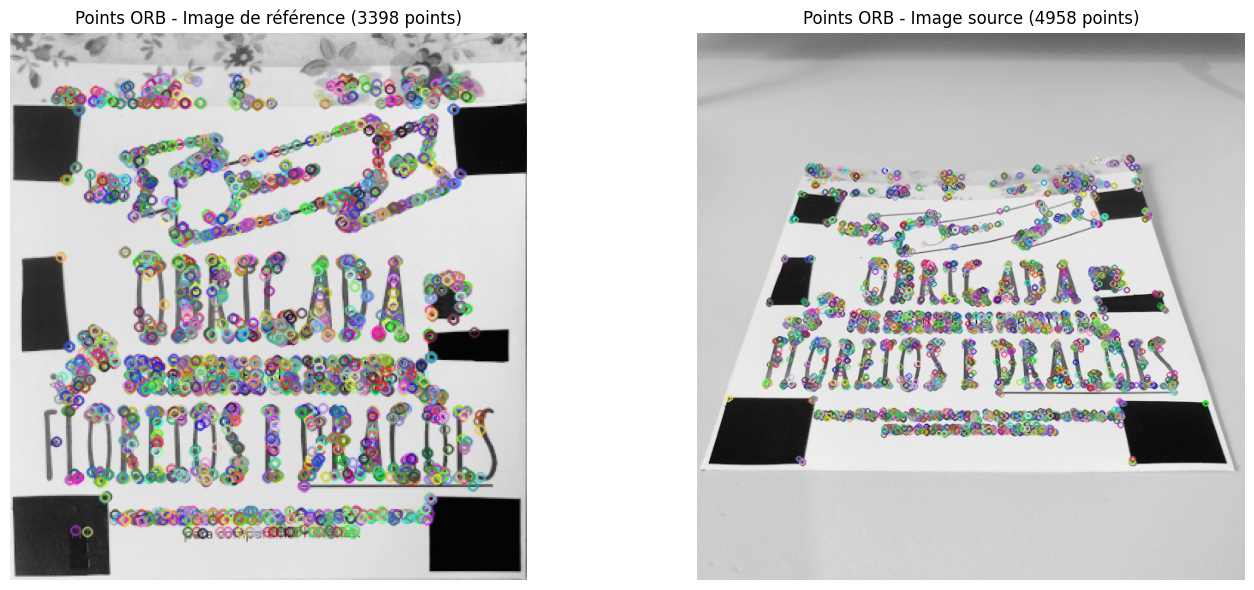

In [27]:
orb = cv2.ORB_create(nfeatures=5000)

kp_model_orb, des_model_orb = orb.detectAndCompute(model_gray, None)
kp_scene_orb, des_scene_orb = orb.detectAndCompute(scene_gray, None)

model_orb_display = cv2.drawKeypoints(model_gray, kp_model_orb, None)
scene_orb_display = cv2.drawKeypoints(scene_gray, kp_scene_orb, None)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(cv2.cvtColor(model_orb_display, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Points ORB - Image de référence ({len(kp_model_orb)} points)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(scene_orb_display, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Points ORB - Image source ({len(kp_scene_orb)} points)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 4. Mise en correspondance des caractéristiques

À ce stade, nous disposons déjà des caractéristiques de l'image de référence et de l'image source, ainsi que de leurs descripteurs. Ces données nous permettent de rechercher des correspondances entre elles.

Une méthode pour faire correspondre une caractéristique de l'image de référence à une caractéristique de l'image source consiste à utiliser le rapport de la distance entre les caractéristiques et à renvoyer la plus proche comme étant la meilleure correspondance.

Après avoir trouvé les correspondances entre les deux images, nous devons décider si l'image de référence a été trouvée dans l'image source ou non. Pour ce faire, un nombre minimum de correspondances à trouver dans l'image est défini. Si, dans l'image source, le nombre de correspondances est supérieur au nombre défini, nous pouvons considérer que l'image de référence a été trouvée dans l'image source.

[Brute-Force Matcher](https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html) pourra être utilisé pour la mise en correspondance des caractéristiques.

Nombre de bonnes correspondances trouvées: 129


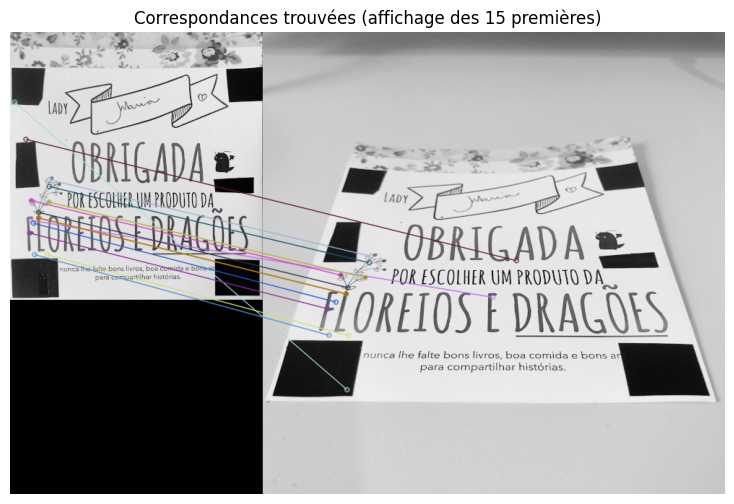

In [28]:
MIN_MATCHES = 10
            
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

kp_model = kp_model_sift
des_model = des_model_sift

kp_scene = kp_scene_sift
des_scene = des_scene_sift

matches = flann.knnMatch(des_model, des_scene, k=2)

good_matches = []
for match_pair in matches:
    if len(match_pair) == 2:
        m, n = match_pair
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)

print(f"Nombre de bonnes correspondances trouvées: {len(good_matches)}")

if len(good_matches) > MIN_MATCHES:
    result = cv2.drawMatches(model_gray, kp_model, scene_gray, kp_scene, 
                            good_matches[:15], None, 
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(15, 6))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(f'Correspondances trouvées (affichage des 15 premières)')
    plt.axis('off')
    plt.show()
else:
    print(f"Pas assez de correspondances ({len(good_matches)} < {MIN_MATCHES})")

### 5. Homographie

Après avoir considéré que l'image de référence a été trouvée dans l'image source, l'étape suivante consiste à trouver un moyen de faire correspondre les points du plan de la surface de l'image de référence au plan de l'image source. Cette transformation est connue sous le nom d'homographie. Une homographie est une transformation projective en 2D qui fait correspondre des points d'un plan (en coordonnées homogènes) à un autre. Nous avons vu cela lors de la création du panorama.


Pour cela, vous pouvez utiliser la fonction [`cv2.findHomography()`](https://docs.opencv.org/3.4/d7/dff/tutorial_feature_homography.html). Si nous lui transmettons l'ensemble des points des deux images, elle trouvera la transformation perspective de cet objet (ici la carte ou surface plane). Nous pouvons alors utiliser [`cv2.perspectiveTransform()`](https://docs.opencv.org/3.4/d7/dff/tutorial_feature_homography.html) pour trouver l'objet. Il faut au moins quatre points corrects pour trouver la transformation.

L'homographie entre les deux images contient des valeurs aberrantes. Ces informations peuvent entraîner des erreurs lors de la mise en correspondance, ce qui peut affecter le résultat. Pour résoudre ce problème, il faudra utiliser l'algorithme RANSAC (RANdom SAmple Consensus) ou LEAST_MEDIAN.

Enfin, une fois l'homographie estimée, vous projeterez les quatre coins de l'image de référence sur l'image source et les connecterez par une ligne (`cv2.polylines`) pour dessiner un polygone. Afficher l'image résultante.




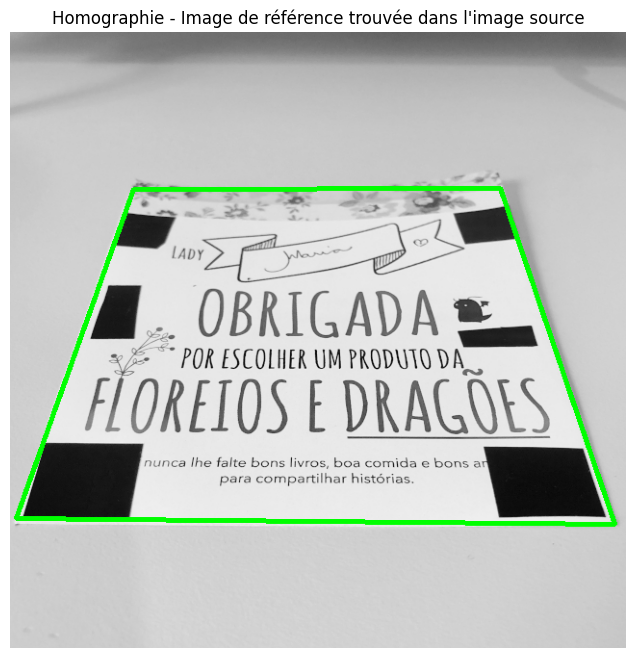

Homographie trouvée


In [29]:
if len(good_matches) > MIN_MATCHES:
    src_pts = np.float32([kp_model[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    
    h, w = model_gray.shape
    
    pts = np.float32([ [0, 0], [w, 0], [w, h], [0, h] ]).reshape(-1, 1, 2)
    
    dst = cv2.perspectiveTransform(pts, H)
    
    scene_color = cv2.cvtColor(scene_gray, cv2.COLOR_GRAY2BGR)
    
    dst = np.int32(dst)
    scene_result = cv2.polylines(scene_color, [dst], True, (0, 255, 0), 3)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(scene_result, cv2.COLOR_BGR2RGB))
    plt.title('Homographie - Image de référence trouvée dans l\'image source')
    plt.axis('off')
    plt.show()
    
    print("Homographie trouvée")
else:
    print(f"Pas assez de correspondances pour calculer l'homographie")

### 6. Estimation de la pose

Pour projeter nos modèles 3D dans l'image, nous devons étendre notre matrice d'homographie. En effet, nous devons être en mesure de projeter non seulement les points contenus dans le plan de la surface de référence (coordonnée z égale à 0), ce que nous pouvons faire maintenant, mais aussi tout point de l'espace de référence (avec une coordonnée z différente de 0).

Pour calculer la position de la caméra (rotation et translation), nous combinons l'homographie estimée avec les paramètres d'une caméra calibrée. Nous nous baserons sur le modèle de caméra sténopé comme vu en cours et vous prendrez comme matrice de calibration la matrice suivante :

```
camera_parameters = np.array([[1000, 0, 320], [0, 1000, 240], [0, 0, 1]])
```

Avec l'homographie et la matrice d'étalonnage de la caméra, nous pouvons maintenant déterminer la transformation relative entre les deux vues ou la matrice de projection. La fonction ci-dessous permettant de calculer la matrice de projection vous est donnée.

 

In [30]:
def projection_matrix(camera_parameters, homography):
    homography = homography * (-1)
    rot_and_transl = np.dot(np.linalg.inv(camera_parameters), homography)
    col_1 = rot_and_transl[:, 0]
    col_2 = rot_and_transl[:, 1]
    col_3 = rot_and_transl[:, 2]
    l = math.sqrt(np.linalg.norm(col_1, 2) * np.linalg.norm(col_2, 2))
    rot_1 = col_1 / l
    rot_2 = col_2 / l
    translation = col_3 / l
    c = rot_1 + rot_2
    p = np.cross(rot_1, rot_2)
    d = np.cross(c, p)
    rot_1 = np.dot(c / np.linalg.norm(c, 2) + d / np.linalg.norm(d, 2), 1 / math.sqrt(2))
    rot_2 = np.dot(c / np.linalg.norm(c, 2) - d / np.linalg.norm(d, 2), 1 / math.sqrt(2))
    rot_3 = np.cross(rot_1, rot_2)
    projection = np.stack((rot_1, rot_2, rot_3, translation)).T
    return np.dot(camera_parameters, projection)
   

### 7. Placement de l'objet 3D


Nous pouvons donc maintenant combiner la correspondance des caractéristiques avec les homographies et l'étalonnage de la caméra pour produire un exemple simple de placement d'un objet 3D dans une image plane.

 Pour cela, vous utiliserez des modèles simples au format Wavefront `.obj` provenant de [claro.io](https://clara.io/). Certains modèles sont donnés dans le répertoire [./Data](./data/). 
 
 Pour le chargement des modèles, vous pourrez utiliser [`OBJFileLoader`](https://www.pygame.org/wiki/OBJFileLoader)fourni par Pygame.


Une fois le modèle chargé, il suffit d'implémenter une fonction qui lit ces données et les projette sur l'image source à l'aide de la matrice de projection obtenue dans la section précédente. Pour ce faire, nous prenons chaque point utilisé pour définir le modèle et le multiplions par la matrice de projection. Une fois cette opération effectuée, il ne reste plus qu'à remplir de couleur les faces du modèle.

Ecrire la fonction `render` mettant en oeuvre ce principe et qui prendra en compte les aspects suivants :

+ facteur d'échelle : Comme nous ne connaissons pas la taille réelle du modèle par rapport à l'image de référence, il se peut que nous devions le mettre à l'échelle afin qu'il ait la taille souhaitée. Il faudra donc prendre en compte une matrice d'échelle pour nous permettre de redimensionner le modèle.
+ Pour que le modèle soit rendu au milieu du cadre de la surface de référence, il est nécessaire, avant de projeter les points sur l'image, de déplacer les coordonnées x et y de tous les points du modèle de la moitié de la largeur et de la hauteur de la surface de référence.
.


In [31]:
from objloader_simple import *

def render(img, obj, projection, model_image, color=False):
    scale = 100
    
    h, w = model_image.shape[:2]
    
    vertices = obj.vertices
    
    vertices_transformed = []
    for vertex in vertices:
        v = np.array([vertex[0] * scale, vertex[1] * scale, vertex[2] * scale])
        v[0] += w / 2.0
        v[1] += h / 2.0
        vertices_transformed.append(v)
    
    projected_vertices = []
    for v in vertices_transformed:
        point_3d = np.array([v[0], v[1], v[2], 1])
        point_2d = projection @ point_3d
        point_2d = point_2d / point_2d[2]
        projected_vertices.append([int(point_2d[0]), int(point_2d[1])])
    
    projected_vertices = np.array(projected_vertices)
    
    for face in obj.faces:
        face_vertices = []
        for vertex_index in face:
            face_vertices.append(projected_vertices[vertex_index - 1])
        
        face_vertices = np.array(face_vertices, dtype=np.int32)
        
        if color:
            color_face = (np.random.randint(0, 255), np.random.randint(0, 255), np.random.randint(0, 255))
        else:
            color_face = (0, 255, 0)
        
        cv2.fillPoly(img, [face_vertices], color_face)
        cv2.polylines(img, [face_vertices], True, (0, 0, 0), 1)
    
    return img

### 8. Mise en place de la chaine complète

Mettre en place la chaine complète avec les objets 3D de votre choix et sur les images de référence et source de vore choix.

In [32]:
camera_parameters = np.array([[1000, 0, 320], [0, 1000, 240], [0, 0, 1]])

if len(good_matches) > MIN_MATCHES:
    src_pts = np.float32([kp_model[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    
    projection = projection_matrix(camera_parameters, H)
    
    obj = OBJ('./data/models/house.obj', swapyz=True)
    
    scene_with_model = scene.copy()
    
    scene_with_model = render(scene_with_model, obj, projection, model_gray, color=False)
    
else:
    print(f"Pas assez de correspondances pour appliquer la transformation ({len(good_matches)} < {MIN_MATCHES})")

Afficher le résultat obtenu

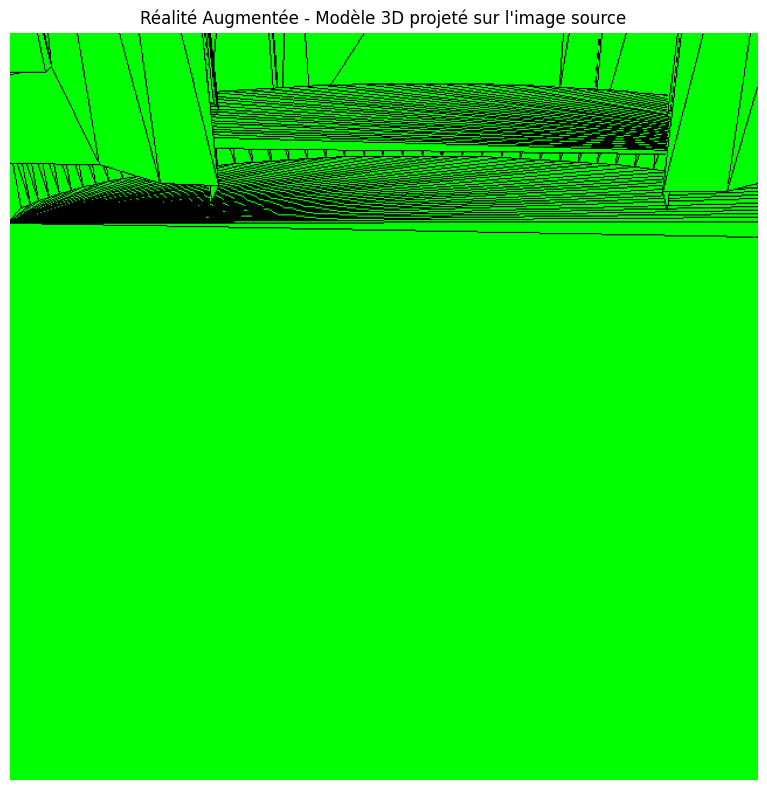

Modèle 3D


In [33]:
if len(good_matches) > MIN_MATCHES:
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(scene_with_model, cv2.COLOR_BGR2RGB))
    plt.title('Réalité Augmentée - Modèle 3D projeté sur l\'image source')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print("Modèle 3D")
else:
    print("Impossible d'afficher le résultat - pas assez de correspondances")

### 9. Mise en place avec une vidéo et votre propre image de référence (optionnel).

Faire maintenant le travail avec votre propre image de référence (surface plane de votre choix) et avec un video. On utilisera pour cela le [module video d'opencv](https://docs.opencv.org/4.x/dd/d43/tutorial_py_video_display.html).



